In [ ]:
Context: https://github.com/JulenErcibengoaTekniker/IberFire/blob/main/notebooks/1.0-DatacubeVisualization/1.2-Visualisation-of-IberFire.ipynb

In [51]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import dask

ds = xr.open_dataset("IberFire.nc", chunks="auto")
print(ds)

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    y_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_spain                                       (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_fire                                        (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    is_near_fire                                   (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=

In [52]:
ds["is_spain"].sum()

<xarray.DataArray 'is_spain' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=uint64, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    description:   Binary mask indicating the Spanish region: 1 for Spanish r...
    valid_values:  {0, 1}
    data_type:     uint8

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm
import ipywidgets as widgets
from datetime import datetime

cmap = ListedColormap([
    "#2c7bb6",  # Sea
    "#d9d9d9",  # Land
    "#66bd63",  # Spain
    "#d7191c",  # Fire
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

legend_labels = ["Sea", "Land", "Spain", "Fire"]
legend_handles = [
    plt.Line2D([0], [0], marker="s", linestyle="",
               markerfacecolor=cmap(i), markersize=10)
    for i in range(4)
]

out = widgets.Output()

def plot_fire_at_date(date):
    with out:
        out.clear_output(wait=True)

        ds_t = ds.sel(time=np.datetime64(date))

        category = xr.zeros_like(ds_t["is_spain"], dtype=np.uint8)

        category = xr.where(ds_t["is_sea"] == 1, 0, category)
        category = xr.where(
            (ds_t["is_sea"] == 0) & (ds_t["is_spain"] == 0),
            1,
            category,
        )
        category = xr.where(
            (ds_t["is_spain"] == 1) & (ds_t["is_fire"] == 0),
            2,
            category,
        )
        category = xr.where(ds_t["is_fire"] == 1, 3, category)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(category, cmap=cmap, norm=norm)
        ax.set_title(f"Fire occurrence – {date}")
        ax.axis("off")

        ax.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            frameon=True
        )

        plt.show()


In [54]:
dates = ds.time.values.astype("datetime64[D]").astype(str)

slider = widgets.SelectionSlider(
    options=dates,
    value=dates[0],
    description="Date",
    layout=widgets.Layout(width="800px"),
    continuous_update=False
)

datepicker = widgets.DatePicker(
    description="Select date",
    value=datetime.strptime(dates[0], "%Y-%m-%d")
)


In [55]:
def on_slider_change(change):
    datepicker.value = datetime.strptime(change["new"], "%Y-%m-%d")
    plot_fire_at_date(change["new"])

def on_datepicker_change(change):
    date_str = change["new"].strftime("%Y-%m-%d")
    slider.value = date_str

slider.observe(on_slider_change, names="value")
datepicker.observe(on_datepicker_change, names="value")


In [56]:
plot_fire_at_date(dates[0])

widgets.VBox([
    slider,
    datepicker,
    out
])

In [47]:
import xarray as xr
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))
days_before = [1, 2, 3, 4, 5]

fire = ds_2022["is_fire"]
fire_start = (fire == 1) & (fire.shift(time=1) == 0)

In [48]:
fire_events = (fire == 1) & (prev_fire == 0)
fire_events = fire_events.stack(points=("y", "x"))

In [49]:
vars_to_analyze = [
    "LAI", "NDVI", "LST",
    "SWI_001", "SWI_005", "SWI_010", "SWI_020",
    "t2m_mean", "RH_mean", "total_precipitation_mean",
    "wind_speed_mean"
]

results = {}  # results[var][day] → list of values

for var in vars_to_analyze:
    print(f"Processing {var}...")
    data_var = ds_2022[var]

    results[var] = {d: [] for d in days_before}

    for d in days_before:
        fire_start_shifted = fire_start.shift(time=d)

        values = (
            data_var
            .where(fire_start_shifted)
            .values
            .ravel()
        )

        values = values[~np.isnan(values)]
        results[var][d].extend(values)

Processing LAI...
Processing NDVI...
Processing LST...
Processing SWI_001...
Processing SWI_005...
Processing SWI_010...
Processing SWI_020...
Processing t2m_mean...
Processing RH_mean...
Processing total_precipitation_mean...
Processing wind_speed_mean...


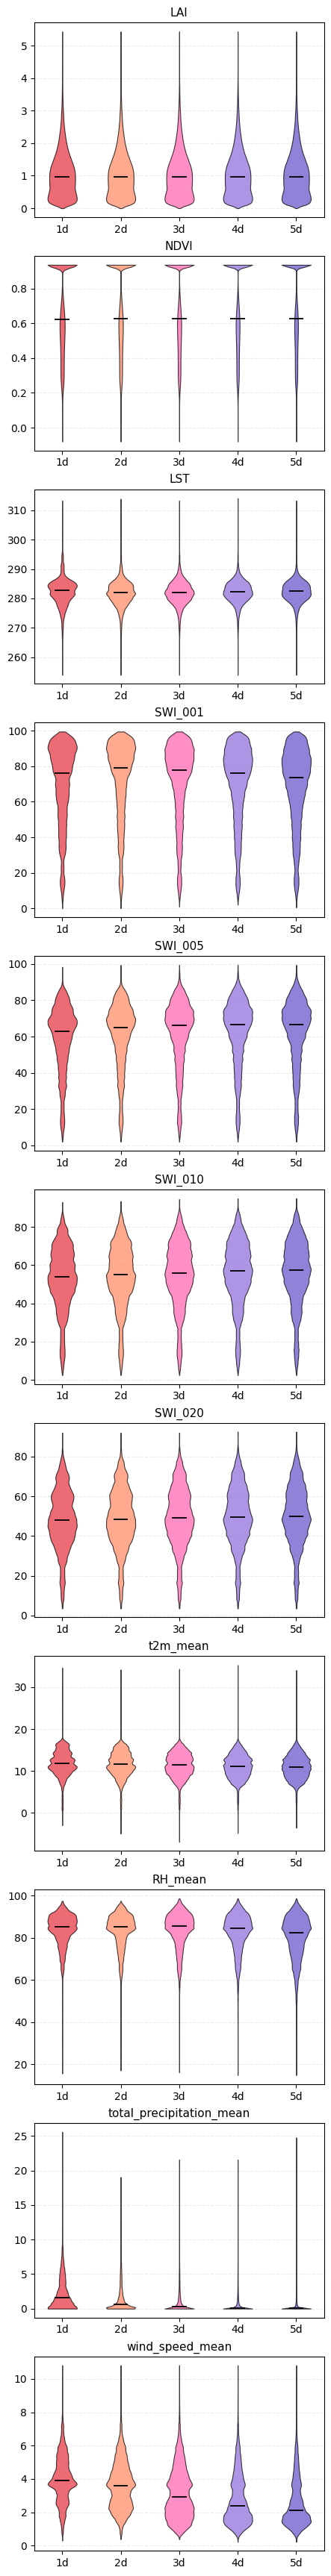

In [50]:
import matplotlib.pyplot as plt
import math

n_vars = len(vars_to_analyze)
n_cols = 1
n_rows = math.ceil(n_vars / n_cols)

day_colors = {
    5: "#6A5ACD",  # purple
    4: "#9370DB",  # lavender
    3: "#FF69B4",  # pink
    2: "#FF8C69",  # coral
    1: "#E63946",  # red
}

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, var in enumerate(vars_to_analyze):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    data = [results[var][d] for d in days_before]

    parts = ax.violinplot(
        data,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Color each violin
    for body, d in zip(parts["bodies"], days_before):
        body.set_facecolor(day_colors[d])
        body.set_edgecolor("black")
        body.set_alpha(0.75)
        body.set_linewidth(0.8)

    # Median styling
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.3)

    # Axis styling
    ax.set_title(var, fontsize=11, pad=6)
    ax.set_xticks(range(1, len(days_before) + 1))
    ax.set_xticklabels([f"{d}d" for d in days_before])
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

In [76]:
ds_2022 = ds.sel(time=slice("2022-06-27", "2022-8-31"))

code_labels = {
    0: "Nodata",
    1: "Andalucía",
    2: "Aragón",
    3: "Principado de Asturias",
    4: "Islas Baleares",
    5: "Canarias",
    6: "Cantabria",
    7: "Castilla y León",
    8: "Castilla - La Mancha",
    9: "Cataluña",
    10: "Comunidad Valenciana",
    11: "Extremadura",
    12: "Galicia",
    13: "Comunidad de Madrid",
    14: "Región de Murcia",
    15: "Comunidad Foral de Navarra",
    16: "País Vasco",
    17: "La Rioja",
    18: "Ceuta",
    19: "Melilla"
}

print(ds_2022["AutonomousCommunities"])
ds_2022 = ds_2022.where((ds_2022["AutonomousCommunities"]==9).compute(), drop = True)
ds_2022

<xarray.DataArray 'AutonomousCommunities' (y: 920, x: 1188)> Size: 2MB
dask.array<open_dataset-AutonomousCommunities, shape=(920, 1188), dtype=uint16, chunksize=(920, 1188), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 7kB 2.492e+06 2.491e+06 ... 1.574e+06 1.573e+06
  * x        (x) float64 10kB 2.675e+06 2.676e+06 ... 3.861e+06 3.862e+06
Attributes: (12/23)
    description:   The Autonomous Communities code. 
    source:        Data obtained from https://data.metabolismofcities.org/lib...
    valid_values:  {1,2, ..., 19}
    00:            Nodata
    01:            Andalucía
    02:            Aragón
    ...            ...
    14:            Región de Murcia
    15:            Comunidad Foral de Navarra
    16:            País Vasco
    17:            La Rioja
    18:            Ceuta
    19:            Melilla


<xarray.Dataset> Size: 615MB
Dimensions:                                        (y: 255, x: 281, time: 66)
Coordinates:
  * y                                              (y) float64 2kB 2.242e+06 ...
  * x                                              (x) float64 2kB 3.489e+06 ...
  * time                                           (time) datetime64[ns] 528B ...
Data variables: (12/261)
    x_index                                        (y, x) float32 287kB dask.array<chunksize=(255, 281), meta=np.ndarray>
    y_index                                        (y, x) float32 287kB dask.array<chunksize=(255, 281), meta=np.ndarray>
    is_spain                                       (y, x) float32 287kB dask.array<chunksize=(255, 281), meta=np.ndarray>
    is_fire                                        (time, y, x) float32 19MB dask.array<chunksize=(66, 230, 281), meta=np.ndarray>
    is_near_fire                                   (time, y, x) float32 19MB dask.array<chunksize=(66, 230, 281), meta=np.ndarray>
    x_coordinate                                   (y, x) float32 287kB dask.array<chunksize=(255, 281), meta=np.ndarray>
    ...                                             ...
    LST                                            (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
    SWI_001                                        (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
    SWI_005                                        (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
    SWI_010                                        (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
    SWI_020                                        (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
    FWI                                            (time, y, x) float32 19MB dask.array<chunksize=(66, 153, 198), meta=np.ndarray>
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

In [72]:
ds

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    y_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_spain                                       (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_fire                                        (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    is_near_fire                                   (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    x_coordinate                                   (y, x) float32 4MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    ...                                             ...
    LST                                            (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
    SWI_001                                        (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
    SWI_005                                        (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
    SWI_010                                        (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
    SWI_020                                        (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
    FWI                                            (time, y, x) float32 27GB dask.array<chunksize=(1042, 154, 198), meta=np.ndarray>
Attributes: (12/17)
    title:                IberFire
    description:          Datacube centered in Spain with 1km x 1km spatial r...
    dimensions:           (y: 920, x: 1188, time: 6241)
    spatial_resolution:   1km x 1km
    temporal_resolution:  Daily
    start_date:           2007-12-01
    ...                   ...
    geospatial_x_max:     3861734.3466
    geospatial_y_min:     1573195.9911000002
    geospatial_y_max:     2492195.9911
    author:               Julen Ercibengoa Calvo
    author_contact:       julen.ercibengoa@gmail.com, julen.ercibengoa@teknik...
    creation_date:        2025-04-04

In [98]:
fire = ds_2022["is_fire"]

fire_start = (fire == 1) & (fire.shift(time=1) == 0)
fire_end   = (fire == 1) & (fire.shift(time=-1) == 0)

<xarray.DataArray 'is_fire' (time: 66, y: 255, x: 281)> Size: 38MB
dask.array<where, shape=(66, 255, 281), dtype=float64, chunksize=(66, 230, 281), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 528B 2022-06-27 2022-06-28 ... 2022-08-31
  * y        (y) float64 2kB 2.242e+06 2.241e+06 ... 1.989e+06 1.988e+06
  * x        (x) float64 2kB 3.489e+06 3.49e+06 ... 3.768e+06 3.769e+06
Attributes:
    description:   Binary mask indicating the presence of fire in that cell (...
    valid_values:  {0, 1}
    data_type:     uint8


In [ ]:
import pandas as pd
import numpy as np

records = []

time = ds_2022["time"].values

for iy in range(25, ds_2022.sizes["y"]):
    print(iy, "out of", ds_2022.sizes["y"])
    for ix in range(25, ds_2022.sizes["x"]):
        fire_ts = fire[:, iy, ix].values
        if not (np.all(np.isnan(fire_ts)) or fire_ts.max() == 0):
            print('fire')
            starts = np.where(fire_start[:, iy, ix])[0]
            ends   = np.where(fire_end[:, iy, ix])[0]
            print(starts)
            print(ends)
            for s, e in zip(starts, ends):
                duration = (e - s + 1)
    
                records.append({
                    "duration": duration,
    
                    # Aspect proportions
                    **{f"aspect_{i}": ds_2022[f"aspect_{i}"][iy, ix].item()
                       for i in range(1, 9)},
    
                    # Terrain stats
                    "elevation_mean": ds_2022["elevation_mean"][iy, ix].item(),
                    "slope_mean": ds_2022["slope_mean"][iy, ix].item(),
                    "roughness_mean": ds_2022["roughness_mean"][iy, ix].item(),
                })

            print(records)


25 out of 255


In [81]:
df_fires = pd.DataFrame(records)

In [86]:
records

[]

In [82]:
aspect_cols = [f"aspect_{i}" for i in range(1, 9)]
df_fires["dominant_aspect"] = df_fires[aspect_cols].idxmax(axis=1)
df_fires["dominant_aspect"] = df_fires["dominant_aspect"].str.extract(r"(\d)").astype(int)

aspect_stats = (
    df_fires
    .groupby("dominant_aspect")["duration"]
    .agg(["mean", "count"])
    .reindex(range(1, 9))
)

angles = np.linspace(0, 2 * np.pi, 9, endpoint=False)
width = 2 * np.pi / 8

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

bars = ax.bar(
    angles,
    aspect_stats["mean"],
    width=width,
    bottom=0,
    color="coral",
    edgecolor="black",
    alpha=0.8
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels([f"A{i}" for i in range(1, 9)])

ax.set_title("Mean fire duration by dominant aspect", pad=20)

plt.show()


KeyError: "None of [Index(['aspect_1', 'aspect_2', 'aspect_3', 'aspect_4', 'aspect_5', 'aspect_6',\n       'aspect_7', 'aspect_8'],\n      dtype='object')] are in the [columns]"